In [1]:
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
import xarray
import glob, os
import math
from scipy.spatial import cKDTree
from netCDF4 import Dataset


#get track data
path='/users/lconlon/'
os.chdir(path)
file='arctic_route_sections.nc'

ds = xarray.open_dataset(file)
lat_A = ds.lat_A.values
lon_A = ds.lon_A.values
dis_A= ds.dis_A.values

lat_B = ds.lat_B.values
lon_B = ds.lon_B.values
dis_B= ds.dis_B.values

lat_C = ds.lat_C.values
lon_C = ds.lon_C.values
dis_C= ds.dis_C.values

lat_D = ds.lat_D.values
lon_D = ds.lon_D.values
dis_D= ds.dis_D.values

lat_E = ds.lat_E.values
lon_E = ds.lon_E.values
dis_E= ds.dis_E.values

lat_F = ds.lat_F.values
lon_F = ds.lon_F.values
dis_F= ds.dis_F.values

lat_G = ds.lat_G.values
lon_G = ds.lon_G.values
dis_G= ds.dis_G.values

lat_H = ds.lat_H.values
lon_H = ds.lon_H.values
dis_H= ds.dis_H.values

lat_I = ds.lat_I.values
lon_I = ds.lon_I.values
dis_I= ds.dis_I.values

lat_J = ds.lat_J.values
lon_J = ds.lon_J.values
dis_J= ds.dis_J.values


In [14]:
#load all data for lookup table
#get lonlat
path='/lustre/scratch4/gennaro/ArcticVanguard/v3.LR.historical_0051/mpas-analysis/'

os.chdir(path)

#get lat lon
files = glob.glob("*01_climo_ncremap.nc")
for file in files:
    ds = xarray.open_dataset(file)
    lat = ds.lat.values
    lon = ds.lon.values
 
##note: RIO 1-3 is going to be made up array, because it should always be positive anyway...
path='/lustre/scratch4/sprice/RIO-plots/RIO-ensemble-data'
os.chdir(path)
ds = xarray.open_dataset("RIO_ensemble_data_PC4.nc")    # I renamed this file correctly (RIO not ROI)
ROI_ens1_pc1 = ds['ROI ensemble 1'].values*0+1     # unfortunately these are stuck w/ the wrong name still
ROI_ens2_pc1 = ds['ROI ensemble 2'].values*0+1
ROI_ens3_pc1 = ds['ROI ensemble 3'].values*0+1
ROI_ens4_pc1 = ds['ROI ensemble 4'].values*0+1
ROI_ens5_pc1 = ds['ROI ensemble 5'].values*0+1
ds = xarray.open_dataset("RIO_ensemble_data_PC4.nc")    # I renamed this file correctly (RIO not ROI)
ROI_ens1_pc2 = ds['ROI ensemble 1'].values*0+1     # unfortunately these are stuck w/ the wrong name still
ROI_ens2_pc2 = ds['ROI ensemble 2'].values*0+1
ROI_ens3_pc2 = ds['ROI ensemble 3'].values*0+1
ROI_ens4_pc2 = ds['ROI ensemble 4'].values*0+1
ROI_ens5_pc2 = ds['ROI ensemble 5'].values*0+1
ds = xarray.open_dataset("RIO_ensemble_data_PC4.nc")    # I renamed this file correctly (RIO not ROI)
ROI_ens1_pc3 = ds['ROI ensemble 1'].values*0+1     # unfortunately these are stuck w/ the wrong name still
ROI_ens2_pc3 = ds['ROI ensemble 2'].values*0+1
ROI_ens3_pc3 = ds['ROI ensemble 3'].values*0+1
ROI_ens4_pc3 = ds['ROI ensemble 4'].values*0+1
ROI_ens5_pc3 = ds['ROI ensemble 5'].values*0+1
ds = xarray.open_dataset("RIO_ensemble_data_PC4.nc")    # I renamed this file correctly (RIO not ROI)
ROI_ens1_pc4 = ds['ROI ensemble 1'].values     # unfortunately these are stuck w/ the wrong name still
ROI_ens2_pc4 = ds['ROI ensemble 2'].values
ROI_ens3_pc4 = ds['ROI ensemble 3'].values
ROI_ens4_pc4 = ds['ROI ensemble 4'].values
ROI_ens5_pc4 = ds['ROI ensemble 5'].values
ds = xarray.open_dataset("RIO_ensemble_data_PC5.nc")    # I renamed this file correctly (RIO not ROI)
ROI_ens1_pc5 = ds['ROI ensemble 1'].values     # unfortunately these are stuck w/ the wrong name still
ROI_ens2_pc5 = ds['ROI ensemble 2'].values
ROI_ens3_pc5 = ds['ROI ensemble 3'].values
ROI_ens4_pc5 = ds['ROI ensemble 4'].values
ROI_ens5_pc5 = ds['ROI ensemble 5'].values
ds = xarray.open_dataset("RIO_ensemble_data_PC6.nc")    # I renamed this file correctly (RIO not ROI)
ROI_ens1_pc6 = ds['ROI ensemble 1'].values     # unfortunately these are stuck w/ the wrong name still
ROI_ens2_pc6 = ds['ROI ensemble 2'].values
ROI_ens3_pc6 = ds['ROI ensemble 3'].values
ROI_ens4_pc6 = ds['ROI ensemble 4'].values
ROI_ens5_pc6 = ds['ROI ensemble 5'].values
ds = xarray.open_dataset("RIO_ensemble_data_PC7.nc")    # I renamed this file correctly (RIO not ROI)
ROI_ens1_pc7 = ds['ROI ensemble 1'].values     # unfortunately these are stuck w/ the wrong name still
ROI_ens2_pc7 = ds['ROI ensemble 2'].values
ROI_ens3_pc7 = ds['ROI ensemble 3'].values
ROI_ens4_pc7 = ds['ROI ensemble 4'].values
ROI_ens5_pc7 = ds['ROI ensemble 5'].values


In [5]:
def ship_speeds(ind1,ind2):
    for PC in ships:
        print(PC)
#limited operations
        if PC==1:
            plot_data=(ROI_ens1_pc1+ROI_ens2_pc1+ROI_ens3_pc1+ROI_ens4_pc1+ROI_ens5_pc1)/5 #ensemble mean
            plot_data=plot_data[:,:,np.int16(ind1),np.int16(ind2)]
            mask = np.isnan(plot_data)
            plot_data[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), plot_data[~mask])
            speeds[(plot_data <-10)]=np.nan
            speeds[plot_data>0]=19
            speeds[(plot_data <0) & (plot_data > -10)]=11 # PC1
        if PC==2:
            plot_data=(ROI_ens1_pc2+ROI_ens2_pc2+ROI_ens3_pc2+ROI_ens4_pc2+ROI_ens5_pc2)/5 #ensemble mean
            plot_data=plot_data[:,:,np.int16(ind1),np.int16(ind2)]
            mask = np.isnan(plot_data)
            plot_data[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), plot_data[~mask])
            speeds[(plot_data <-10)]=np.nan
            speeds[plot_data>0]=16.5
            speeds[(plot_data <0) & (plot_data > -10)]=8 # 
        if PC==3:
            plot_data=(ROI_ens1_pc3+ROI_ens2_pc3+ROI_ens3_pc3+ROI_ens4_pc3+ROI_ens5_pc3)/5 #ensemble mean
            plot_data=plot_data[:,:,np.int16(ind1),np.int16(ind2)]
            mask = np.isnan(plot_data)
            plot_data[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), plot_data[~mask])
            speeds[(plot_data <-10)]=np.nan
            speeds[plot_data>0]=16
            speeds[(plot_data <0) & (plot_data > -10)]=5 # 
        if PC==4:
            plot_data=(ROI_ens1_pc4+ROI_ens2_pc4+ROI_ens3_pc4+ROI_ens4_pc4+ROI_ens5_pc4)/5 #ensemble mean
            plot_data=plot_data[:,:,np.int16(ind1),np.int16(ind2)]
            mask = np.isnan(plot_data)
            plot_data[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), plot_data[~mask])
            speeds[(plot_data <-10)]=np.nan
            speeds[plot_data>0]=15
            speeds[(plot_data <0) & (plot_data > -10)]=5 # 
        if PC==5:
            plot_data=(ROI_ens1_pc5+ROI_ens2_pc5+ROI_ens3_pc5+ROI_ens4_pc5+ROI_ens5_pc5)/5 #ensemble mean
            plot_data=plot_data[:,:,np.int16(ind1),np.int16(ind2)]
            mask = np.isnan(plot_data)
            plot_data[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), plot_data[~mask])
            speeds[(plot_data <-10)]=np.nan
            speeds[plot_data>0]=14
            speeds[(plot_data <0) & (plot_data > -10)]=5 # 
        if PC==6:
            plot_data=(ROI_ens1_pc6+ROI_ens2_pc6+ROI_ens3_pc6+ROI_ens4_pc6+ROI_ens5_pc6)/5 #ensemble mean
            plot_data=plot_data[:,:,np.int16(ind1),np.int16(ind2)]
            mask = np.isnan(plot_data)
            plot_data[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), plot_data[~mask])
            speeds[(plot_data <-10)]=np.nan
            speeds[plot_data>0]=14
            speeds[(plot_data <0) & (plot_data > -10)]=3 # 3 knots for PC6
        if PC==7:
            plot_data=(ROI_ens1_pc7+ROI_ens2_pc7+ROI_ens3_pc7+ROI_ens4_pc7+ROI_ens5_pc7)/5 #ensemble mean
            plot_data=plot_data[:,:,np.int16(ind1),np.int16(ind2)]
            mask = np.isnan(plot_data)
            plot_data[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), plot_data[~mask])
            speeds[(plot_data <-10)]=np.nan
            speeds[plot_data>0]=14
            speeds[(plot_data <0) & (plot_data > -10)]=3 # 3 knots for PC6
        time=1/speeds
        time=np.sum(time,2)/24
        time2[:,:,PC]=time                                  
    return time2

In [6]:

ships=[1, 2, 3, 4, 5, 6, 7]


# the Heatmap table
#******************************
# Change these things if you want:
print('A')
trans_lat=lat_A  #Also have to select transect here
trans_lon=lon_A
trans_dist=dis_A

#******************************
time2=np.zeros((50,12,8))
tree = cKDTree(list(zip(lon.flatten(), lat.flatten())))
d, inds = tree.query(list(zip(trans_lon, trans_lat)), k = 4)


number = inds[:,0]/601
#do some magic here to get indices
ind1=np.zeros((len(number)))
ind2=np.zeros((len(number)))

for i in np.arange(0,len(number)):
    num=number[i]
    def split_float(num):
        integer_part = math.trunc(num)
        decimal_part = num - integer_part
        return integer_part, decimal_part


    integer, decimal = split_float(num)
    ind1[i]=np.int16(integer)
    ind2[i]=np.int16(601*decimal)

speeds=np.zeros((50,12,len(trans_dist)))
ship_speeds(ind1,ind2)

decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
mean_springA=np.vstack((decade1mean_spring,decade2mean_spring,decade3mean_spring,decade4mean_spring,decade5mean_spring))

decade1mean_summer=np.nanmean(np.nanmean(time2[0:10,6:9,1:],0),0) #jas
decade2mean_summer=np.nanmean(np.nanmean(time2[10:20,6:9,1:],0),0)
decade3mean_summer=np.nanmean(np.nanmean(time2[20:30,6:9,1:],0),0)
decade4mean_summer=np.nanmean(np.nanmean(time2[30:40,6:9,1:],0),0)
decade5mean_summer=np.nanmean(np.nanmean(time2[40:50,6:9,1:],0),0)
mean_summerA=np.vstack((decade1mean_summer,decade2mean_summer,decade3mean_summer,decade4mean_summer,decade5mean_summer))

decade1mean_fall=np.nanmean(np.nanmean(time2[0:10,9:12,1:],0),0) #ond
decade2mean_fall=np.nanmean(np.nanmean(time2[10:20,9:12,1:],0),0)
decade3mean_fall=np.nanmean(np.nanmean(time2[20:30,9:12,1:],0),0)
decade4mean_fall=np.nanmean(np.nanmean(time2[30:40,9:12,1:],0),0)
decade5mean_fall=np.nanmean(np.nanmean(time2[40:50,9:12,1:],0),0)
mean_fallA=np.vstack((decade1mean_fall,decade2mean_fall,decade3mean_fall,decade4mean_fall,decade5mean_fall))

decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
decade2mean_winter=np.nanmean(np.nanmean(time2[10:20,0:3,1:],0),0)
decade3mean_winter=np.nanmean(np.nanmean(time2[20:30,0:3,1:],0),0)
decade4mean_winter=np.nanmean(np.nanmean(time2[30:40,0:3,1:],0),0)
decade5mean_winter=np.nanmean(np.nanmean(time2[40:50,0:3,1:],0),0)
mean_winterA=np.vstack((decade1mean_winter,decade2mean_winter,decade3mean_winter,decade4mean_winter,decade5mean_winter))

#******************************
# Change these things if you want:
print('B')
trans_lat=lat_B  #Also have to select transect here
trans_lon=lon_B
trans_dist=dis_B

#******************************
time2=np.zeros((50,12,8))
tree = cKDTree(list(zip(lon.flatten(), lat.flatten())))
d, inds = tree.query(list(zip(trans_lon, trans_lat)), k = 4)


number = inds[:,0]/601
#do some magic here to get indices
ind1=np.zeros((len(number)))
ind2=np.zeros((len(number)))

for i in np.arange(0,len(number)):
    num=number[i]
    def split_float(num):
        integer_part = math.trunc(num)
        decimal_part = num - integer_part
        return integer_part, decimal_part


    integer, decimal = split_float(num)
    ind1[i]=np.int16(integer)
    ind2[i]=np.int16(601*decimal)

speeds=np.zeros((50,12,len(trans_dist)))
ship_speeds(ind1,ind2)

decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
mean_springB=np.vstack((decade1mean_spring,decade2mean_spring,decade3mean_spring,decade4mean_spring,decade5mean_spring))

decade1mean_summer=np.nanmean(np.nanmean(time2[0:10,6:9,1:],0),0) #jas
decade2mean_summer=np.nanmean(np.nanmean(time2[10:20,6:9,1:],0),0)
decade3mean_summer=np.nanmean(np.nanmean(time2[20:30,6:9,1:],0),0)
decade4mean_summer=np.nanmean(np.nanmean(time2[30:40,6:9,1:],0),0)
decade5mean_summer=np.nanmean(np.nanmean(time2[40:50,6:9,1:],0),0)
mean_summerB=np.vstack((decade1mean_summer,decade2mean_summer,decade3mean_summer,decade4mean_summer,decade5mean_summer))

decade1mean_fall=np.nanmean(np.nanmean(time2[0:10,9:12,1:],0),0) #ond
decade2mean_fall=np.nanmean(np.nanmean(time2[10:20,9:12,1:],0),0)
decade3mean_fall=np.nanmean(np.nanmean(time2[20:30,9:12,1:],0),0)
decade4mean_fall=np.nanmean(np.nanmean(time2[30:40,9:12,1:],0),0)
decade5mean_fall=np.nanmean(np.nanmean(time2[40:50,9:12,1:],0),0)
mean_fallB=np.vstack((decade1mean_fall,decade2mean_fall,decade3mean_fall,decade4mean_fall,decade5mean_fall))

decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
decade2mean_winter=np.nanmean(np.nanmean(time2[10:20,0:3,1:],0),0)
decade3mean_winter=np.nanmean(np.nanmean(time2[20:30,0:3,1:],0),0)
decade4mean_winter=np.nanmean(np.nanmean(time2[30:40,0:3,1:],0),0)
decade5mean_winter=np.nanmean(np.nanmean(time2[40:50,0:3,1:],0),0)
mean_winterB=np.vstack((decade1mean_winter,decade2mean_winter,decade3mean_winter,decade4mean_winter,decade5mean_winter))

#******************************
# Change these things if you want:
print('C')
trans_lat=lat_C  #Also have to select transect here
trans_lon=lon_C
trans_dist=dis_C

#******************************
time2=np.zeros((50,12,8))
tree = cKDTree(list(zip(lon.flatten(), lat.flatten())))
d, inds = tree.query(list(zip(trans_lon, trans_lat)), k = 4)


number = inds[:,0]/601
#do some magic here to get indices
ind1=np.zeros((len(number)))
ind2=np.zeros((len(number)))

for i in np.arange(0,len(number)):
    num=number[i]
    def split_float(num):
        integer_part = math.trunc(num)
        decimal_part = num - integer_part
        return integer_part, decimal_part


    integer, decimal = split_float(num)
    ind1[i]=np.int16(integer)
    ind2[i]=np.int16(601*decimal)

speeds=np.zeros((50,12,len(trans_dist)))
ship_speeds(ind1,ind2)

decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
mean_springC=np.vstack((decade1mean_spring,decade2mean_spring,decade3mean_spring,decade4mean_spring,decade5mean_spring))

decade1mean_summer=np.nanmean(np.nanmean(time2[0:10,6:9,1:],0),0) #jas
decade2mean_summer=np.nanmean(np.nanmean(time2[10:20,6:9,1:],0),0)
decade3mean_summer=np.nanmean(np.nanmean(time2[20:30,6:9,1:],0),0)
decade4mean_summer=np.nanmean(np.nanmean(time2[30:40,6:9,1:],0),0)
decade5mean_summer=np.nanmean(np.nanmean(time2[40:50,6:9,1:],0),0)
mean_summerC=np.vstack((decade1mean_summer,decade2mean_summer,decade3mean_summer,decade4mean_summer,decade5mean_summer))

decade1mean_fall=np.nanmean(np.nanmean(time2[0:10,9:12,1:],0),0) #ond
decade2mean_fall=np.nanmean(np.nanmean(time2[10:20,9:12,1:],0),0)
decade3mean_fall=np.nanmean(np.nanmean(time2[20:30,9:12,1:],0),0)
decade4mean_fall=np.nanmean(np.nanmean(time2[30:40,9:12,1:],0),0)
decade5mean_fall=np.nanmean(np.nanmean(time2[40:50,9:12,1:],0),0)
mean_fallC=np.vstack((decade1mean_fall,decade2mean_fall,decade3mean_fall,decade4mean_fall,decade5mean_fall))

decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
decade2mean_winter=np.nanmean(np.nanmean(time2[10:20,0:3,1:],0),0)
decade3mean_winter=np.nanmean(np.nanmean(time2[20:30,0:3,1:],0),0)
decade4mean_winter=np.nanmean(np.nanmean(time2[30:40,0:3,1:],0),0)
decade5mean_winter=np.nanmean(np.nanmean(time2[40:50,0:3,1:],0),0)
mean_winterC=np.vstack((decade1mean_winter,decade2mean_winter,decade3mean_winter,decade4mean_winter,decade5mean_winter))

#******************************
# Change these things if you want:
print('D')
trans_lat=lat_D  #Also have to select transect here
trans_lon=lon_D
trans_dist=dis_D

#******************************
time2=np.zeros((50,12,8))
tree = cKDTree(list(zip(lon.flatten(), lat.flatten())))
d, inds = tree.query(list(zip(trans_lon, trans_lat)), k = 4)


number = inds[:,0]/601
#do some magic here to get indices
ind1=np.zeros((len(number)))
ind2=np.zeros((len(number)))

for i in np.arange(0,len(number)):
    num=number[i]
    def split_float(num):
        integer_part = math.trunc(num)
        decimal_part = num - integer_part
        return integer_part, decimal_part


    integer, decimal = split_float(num)
    ind1[i]=np.int16(integer)
    ind2[i]=np.int16(601*decimal)

speeds=np.zeros((50,12,len(trans_dist)))
ship_speeds(ind1,ind2)

decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
mean_springD=np.vstack((decade1mean_spring,decade2mean_spring,decade3mean_spring,decade4mean_spring,decade5mean_spring))

decade1mean_summer=np.nanmean(np.nanmean(time2[0:10,6:9,1:],0),0) #jas
decade2mean_summer=np.nanmean(np.nanmean(time2[10:20,6:9,1:],0),0)
decade3mean_summer=np.nanmean(np.nanmean(time2[20:30,6:9,1:],0),0)
decade4mean_summer=np.nanmean(np.nanmean(time2[30:40,6:9,1:],0),0)
decade5mean_summer=np.nanmean(np.nanmean(time2[40:50,6:9,1:],0),0)
mean_summerD=np.vstack((decade1mean_summer,decade2mean_summer,decade3mean_summer,decade4mean_summer,decade5mean_summer))

decade1mean_fall=np.nanmean(np.nanmean(time2[0:10,9:12,1:],0),0) #ond
decade2mean_fall=np.nanmean(np.nanmean(time2[10:20,9:12,1:],0),0)
decade3mean_fall=np.nanmean(np.nanmean(time2[20:30,9:12,1:],0),0)
decade4mean_fall=np.nanmean(np.nanmean(time2[30:40,9:12,1:],0),0)
decade5mean_fall=np.nanmean(np.nanmean(time2[40:50,9:12,1:],0),0)
mean_fallD=np.vstack((decade1mean_fall,decade2mean_fall,decade3mean_fall,decade4mean_fall,decade5mean_fall))

decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
decade2mean_winter=np.nanmean(np.nanmean(time2[10:20,0:3,1:],0),0)
decade3mean_winter=np.nanmean(np.nanmean(time2[20:30,0:3,1:],0),0)
decade4mean_winter=np.nanmean(np.nanmean(time2[30:40,0:3,1:],0),0)
decade5mean_winter=np.nanmean(np.nanmean(time2[40:50,0:3,1:],0),0)
mean_winterD=np.vstack((decade1mean_winter,decade2mean_winter,decade3mean_winter,decade4mean_winter,decade5mean_winter))




A
1
2
3
4
5
6
7


/tmp/ipykernel_39880/4289795085.py:41: RuntimeWarning: Mean of empty slice
  decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
/tmp/ipykernel_39880/4289795085.py:42: RuntimeWarning: Mean of empty slice
  decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
/tmp/ipykernel_39880/4289795085.py:43: RuntimeWarning: Mean of empty slice
  decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
/tmp/ipykernel_39880/4289795085.py:44: RuntimeWarning: Mean of empty slice
  decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
/tmp/ipykernel_39880/4289795085.py:62: RuntimeWarning: Mean of empty slice
  decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
/tmp/ipykernel_39880/4289795085.py:63: RuntimeWarning: Mean of empty slice
  decade2mean_winter=np.nanmean(np.nanmean(time2[10:20,0:3,1:],0),0)
/tmp/ipykernel_39880/4289795085.py:64: RuntimeWarning: Mean of empty slice
  decade3mean_winter=np.nanmean(np.nanmean(time2[20:

B
1
2
3
4
5
6
7


/tmp/ipykernel_39880/4289795085.py:102: RuntimeWarning: Mean of empty slice
  decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
/tmp/ipykernel_39880/4289795085.py:103: RuntimeWarning: Mean of empty slice
  decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
/tmp/ipykernel_39880/4289795085.py:104: RuntimeWarning: Mean of empty slice
  decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
/tmp/ipykernel_39880/4289795085.py:105: RuntimeWarning: Mean of empty slice
  decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
/tmp/ipykernel_39880/4289795085.py:106: RuntimeWarning: Mean of empty slice
  decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
/tmp/ipykernel_39880/4289795085.py:123: RuntimeWarning: Mean of empty slice
  decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
/tmp/ipykernel_39880/4289795085.py:124: RuntimeWarning: Mean of empty slice
  decade2mean_winter=np.nanmean(np.nanmean(ti

C
1
2
3
4
5
6
7


/tmp/ipykernel_39880/4289795085.py:163: RuntimeWarning: Mean of empty slice
  decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
/tmp/ipykernel_39880/4289795085.py:164: RuntimeWarning: Mean of empty slice
  decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
/tmp/ipykernel_39880/4289795085.py:165: RuntimeWarning: Mean of empty slice
  decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
/tmp/ipykernel_39880/4289795085.py:166: RuntimeWarning: Mean of empty slice
  decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
/tmp/ipykernel_39880/4289795085.py:167: RuntimeWarning: Mean of empty slice
  decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
/tmp/ipykernel_39880/4289795085.py:184: RuntimeWarning: Mean of empty slice
  decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
/tmp/ipykernel_39880/4289795085.py:185: RuntimeWarning: Mean of empty slice
  decade2mean_winter=np.nanmean(np.nanmean(ti

D
1
2
3
4
5
6
7


In [7]:
#******************************
# Change these things if you want:
print('E')
trans_lat=lat_E  #Also have to select transect here
trans_lon=lon_E
trans_dist=dis_E

#******************************
time2=np.zeros((50,12,8))
tree = cKDTree(list(zip(lon.flatten(), lat.flatten())))
d, inds = tree.query(list(zip(trans_lon, trans_lat)), k = 4)


number = inds[:,0]/601
#do some magic here to get indices
ind1=np.zeros((len(number)))
ind2=np.zeros((len(number)))

for i in np.arange(0,len(number)):
    num=number[i]
    def split_float(num):
        integer_part = math.trunc(num)
        decimal_part = num - integer_part
        return integer_part, decimal_part


    integer, decimal = split_float(num)
    ind1[i]=np.int16(integer)
    ind2[i]=np.int16(601*decimal)

speeds=np.zeros((50,12,len(trans_dist)))
ship_speeds(ind1,ind2)

decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
mean_springE=np.vstack((decade1mean_spring,decade2mean_spring,decade3mean_spring,decade4mean_spring,decade5mean_spring))

decade1mean_summer=np.nanmean(np.nanmean(time2[0:10,6:9,1:],0),0) #jas
decade2mean_summer=np.nanmean(np.nanmean(time2[10:20,6:9,1:],0),0)
decade3mean_summer=np.nanmean(np.nanmean(time2[20:30,6:9,1:],0),0)
decade4mean_summer=np.nanmean(np.nanmean(time2[30:40,6:9,1:],0),0)
decade5mean_summer=np.nanmean(np.nanmean(time2[40:50,6:9,1:],0),0)
mean_summerE=np.vstack((decade1mean_summer,decade2mean_summer,decade3mean_summer,decade4mean_summer,decade5mean_summer))

decade1mean_fall=np.nanmean(np.nanmean(time2[0:10,9:12,1:],0),0) #ond
decade2mean_fall=np.nanmean(np.nanmean(time2[10:20,9:12,1:],0),0)
decade3mean_fall=np.nanmean(np.nanmean(time2[20:30,9:12,1:],0),0)
decade4mean_fall=np.nanmean(np.nanmean(time2[30:40,9:12,1:],0),0)
decade5mean_fall=np.nanmean(np.nanmean(time2[40:50,9:12,1:],0),0)
mean_fallE=np.vstack((decade1mean_fall,decade2mean_fall,decade3mean_fall,decade4mean_fall,decade5mean_fall))

decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
decade2mean_winter=np.nanmean(np.nanmean(time2[10:20,0:3,1:],0),0)
decade3mean_winter=np.nanmean(np.nanmean(time2[20:30,0:3,1:],0),0)
decade4mean_winter=np.nanmean(np.nanmean(time2[30:40,0:3,1:],0),0)
decade5mean_winter=np.nanmean(np.nanmean(time2[40:50,0:3,1:],0),0)
mean_winterE=np.vstack((decade1mean_winter,decade2mean_winter,decade3mean_winter,decade4mean_winter,decade5mean_winter))


#******************************
# Change these things if you want:
print('F')
trans_lat=lat_F  #Also have to select transect here
trans_lon=lon_F
trans_dist=dis_F

#******************************
time2=np.zeros((50,12,8))
tree = cKDTree(list(zip(lon.flatten(), lat.flatten())))
d, inds = tree.query(list(zip(trans_lon, trans_lat)), k = 4)


number = inds[:,0]/601
#do some magic here to get indices
ind1=np.zeros((len(number)))
ind2=np.zeros((len(number)))

for i in np.arange(0,len(number)):
    num=number[i]
    def split_float(num):
        integer_part = math.trunc(num)
        decimal_part = num - integer_part
        return integer_part, decimal_part


    integer, decimal = split_float(num)
    ind1[i]=np.int16(integer)
    ind2[i]=np.int16(601*decimal)

speeds=np.zeros((50,12,len(trans_dist)))
ship_speeds(ind1,ind2)

decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
mean_springF=np.vstack((decade1mean_spring,decade2mean_spring,decade3mean_spring,decade4mean_spring,decade5mean_spring))

decade1mean_summer=np.nanmean(np.nanmean(time2[0:10,6:9,1:],0),0) #jas
decade2mean_summer=np.nanmean(np.nanmean(time2[10:20,6:9,1:],0),0)
decade3mean_summer=np.nanmean(np.nanmean(time2[20:30,6:9,1:],0),0)
decade4mean_summer=np.nanmean(np.nanmean(time2[30:40,6:9,1:],0),0)
decade5mean_summer=np.nanmean(np.nanmean(time2[40:50,6:9,1:],0),0)
mean_summerF=np.vstack((decade1mean_summer,decade2mean_summer,decade3mean_summer,decade4mean_summer,decade5mean_summer))

decade1mean_fall=np.nanmean(np.nanmean(time2[0:10,9:12,1:],0),0) #ond
decade2mean_fall=np.nanmean(np.nanmean(time2[10:20,9:12,1:],0),0)
decade3mean_fall=np.nanmean(np.nanmean(time2[20:30,9:12,1:],0),0)
decade4mean_fall=np.nanmean(np.nanmean(time2[30:40,9:12,1:],0),0)
decade5mean_fall=np.nanmean(np.nanmean(time2[40:50,9:12,1:],0),0)
mean_fallF=np.vstack((decade1mean_fall,decade2mean_fall,decade3mean_fall,decade4mean_fall,decade5mean_fall))

decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
decade2mean_winter=np.nanmean(np.nanmean(time2[10:20,0:3,1:],0),0)
decade3mean_winter=np.nanmean(np.nanmean(time2[20:30,0:3,1:],0),0)
decade4mean_winter=np.nanmean(np.nanmean(time2[30:40,0:3,1:],0),0)
decade5mean_winter=np.nanmean(np.nanmean(time2[40:50,0:3,1:],0),0)
mean_winterF=np.vstack((decade1mean_winter,decade2mean_winter,decade3mean_winter,decade4mean_winter,decade5mean_winter))


#******************************
# Change these things if you want:
print('G')
trans_lat=lat_G  #Also have to select transect here
trans_lon=lon_G
trans_dist=dis_G

#******************************
time2=np.zeros((50,12,8))
tree = cKDTree(list(zip(lon.flatten(), lat.flatten())))
d, inds = tree.query(list(zip(trans_lon, trans_lat)), k = 4)


number = inds[:,0]/601
#do some magic here to get indices
ind1=np.zeros((len(number)))
ind2=np.zeros((len(number)))

for i in np.arange(0,len(number)):
    num=number[i]
    def split_float(num):
        integer_part = math.trunc(num)
        decimal_part = num - integer_part
        return integer_part, decimal_part


    integer, decimal = split_float(num)
    ind1[i]=np.int16(integer)
    ind2[i]=np.int16(601*decimal)

speeds=np.zeros((50,12,len(trans_dist)))
ship_speeds(ind1,ind2)

decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
mean_springG=np.vstack((decade1mean_spring,decade2mean_spring,decade3mean_spring,decade4mean_spring,decade5mean_spring))

decade1mean_summer=np.nanmean(np.nanmean(time2[0:10,6:9,1:],0),0) #jas
decade2mean_summer=np.nanmean(np.nanmean(time2[10:20,6:9,1:],0),0)
decade3mean_summer=np.nanmean(np.nanmean(time2[20:30,6:9,1:],0),0)
decade4mean_summer=np.nanmean(np.nanmean(time2[30:40,6:9,1:],0),0)
decade5mean_summer=np.nanmean(np.nanmean(time2[40:50,6:9,1:],0),0)
mean_summerG=np.vstack((decade1mean_summer,decade2mean_summer,decade3mean_summer,decade4mean_summer,decade5mean_summer))

decade1mean_fall=np.nanmean(np.nanmean(time2[0:10,9:12,1:],0),0) #ond
decade2mean_fall=np.nanmean(np.nanmean(time2[10:20,9:12,1:],0),0)
decade3mean_fall=np.nanmean(np.nanmean(time2[20:30,9:12,1:],0),0)
decade4mean_fall=np.nanmean(np.nanmean(time2[30:40,9:12,1:],0),0)
decade5mean_fall=np.nanmean(np.nanmean(time2[40:50,9:12,1:],0),0)
mean_fallG=np.vstack((decade1mean_fall,decade2mean_fall,decade3mean_fall,decade4mean_fall,decade5mean_fall))

decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
decade2mean_winter=np.nanmean(np.nanmean(time2[10:20,0:3,1:],0),0)
decade3mean_winter=np.nanmean(np.nanmean(time2[20:30,0:3,1:],0),0)
decade4mean_winter=np.nanmean(np.nanmean(time2[30:40,0:3,1:],0),0)
decade5mean_winter=np.nanmean(np.nanmean(time2[40:50,0:3,1:],0),0)
mean_winterG=np.vstack((decade1mean_winter,decade2mean_winter,decade3mean_winter,decade4mean_winter,decade5mean_winter))




E
1
2
3
4
5
6
7


/tmp/ipykernel_39880/136652725.py:34: RuntimeWarning: Mean of empty slice
  decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
/tmp/ipykernel_39880/136652725.py:35: RuntimeWarning: Mean of empty slice
  decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
/tmp/ipykernel_39880/136652725.py:36: RuntimeWarning: Mean of empty slice
  decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
/tmp/ipykernel_39880/136652725.py:37: RuntimeWarning: Mean of empty slice
  decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
/tmp/ipykernel_39880/136652725.py:55: RuntimeWarning: Mean of empty slice
  decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
/tmp/ipykernel_39880/136652725.py:56: RuntimeWarning: Mean of empty slice
  decade2mean_winter=np.nanmean(np.nanmean(time2[10:20,0:3,1:],0),0)
/tmp/ipykernel_39880/136652725.py:57: RuntimeWarning: Mean of empty slice
  decade3mean_winter=np.nanmean(np.nanmean(time2[20:30,0:3,

F
1
2
3
4
5
6
7


/tmp/ipykernel_39880/136652725.py:96: RuntimeWarning: Mean of empty slice
  decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
/tmp/ipykernel_39880/136652725.py:97: RuntimeWarning: Mean of empty slice
  decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
/tmp/ipykernel_39880/136652725.py:98: RuntimeWarning: Mean of empty slice
  decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
/tmp/ipykernel_39880/136652725.py:99: RuntimeWarning: Mean of empty slice
  decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
/tmp/ipykernel_39880/136652725.py:100: RuntimeWarning: Mean of empty slice
  decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
/tmp/ipykernel_39880/136652725.py:117: RuntimeWarning: Mean of empty slice
  decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
/tmp/ipykernel_39880/136652725.py:118: RuntimeWarning: Mean of empty slice
  decade2mean_winter=np.nanmean(np.nanmean(time2[10:20,0

G
1
2
3
4
5
6
7


/tmp/ipykernel_39880/136652725.py:158: RuntimeWarning: Mean of empty slice
  decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
/tmp/ipykernel_39880/136652725.py:159: RuntimeWarning: Mean of empty slice
  decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
/tmp/ipykernel_39880/136652725.py:160: RuntimeWarning: Mean of empty slice
  decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
/tmp/ipykernel_39880/136652725.py:161: RuntimeWarning: Mean of empty slice
  decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
/tmp/ipykernel_39880/136652725.py:162: RuntimeWarning: Mean of empty slice
  decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
/tmp/ipykernel_39880/136652725.py:179: RuntimeWarning: Mean of empty slice
  decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
/tmp/ipykernel_39880/136652725.py:180: RuntimeWarning: Mean of empty slice
  decade2mean_winter=np.nanmean(np.nanmean(time2[10:

In [8]:
#******************************
# Change these things if you want:
print('H')
trans_lat=lat_H  #Also have to select transect here
trans_lon=lon_H
trans_dist=dis_H

#******************************
time2=np.zeros((50,12,8))
tree = cKDTree(list(zip(lon.flatten(), lat.flatten())))
d, inds = tree.query(list(zip(trans_lon, trans_lat)), k = 4)


number = inds[:,0]/601
#do some magic here to get indices
ind1=np.zeros((len(number)))
ind2=np.zeros((len(number)))

for i in np.arange(0,len(number)):
    num=number[i]
    def split_float(num):
        integer_part = math.trunc(num)
        decimal_part = num - integer_part
        return integer_part, decimal_part


    integer, decimal = split_float(num)
    ind1[i]=np.int16(integer)
    ind2[i]=np.int16(601*decimal)

speeds=np.zeros((50,12,len(trans_dist)))
ship_speeds(ind1,ind2)

decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
mean_springH=np.vstack((decade1mean_spring,decade2mean_spring,decade3mean_spring,decade4mean_spring,decade5mean_spring))

decade1mean_summer=np.nanmean(np.nanmean(time2[0:10,6:9,1:],0),0) #jas
decade2mean_summer=np.nanmean(np.nanmean(time2[10:20,6:9,1:],0),0)
decade3mean_summer=np.nanmean(np.nanmean(time2[20:30,6:9,1:],0),0)
decade4mean_summer=np.nanmean(np.nanmean(time2[30:40,6:9,1:],0),0)
decade5mean_summer=np.nanmean(np.nanmean(time2[40:50,6:9,1:],0),0)
mean_summerH=np.vstack((decade1mean_summer,decade2mean_summer,decade3mean_summer,decade4mean_summer,decade5mean_summer))

decade1mean_fall=np.nanmean(np.nanmean(time2[0:10,9:12,1:],0),0) #ond
decade2mean_fall=np.nanmean(np.nanmean(time2[10:20,9:12,1:],0),0)
decade3mean_fall=np.nanmean(np.nanmean(time2[20:30,9:12,1:],0),0)
decade4mean_fall=np.nanmean(np.nanmean(time2[30:40,9:12,1:],0),0)
decade5mean_fall=np.nanmean(np.nanmean(time2[40:50,9:12,1:],0),0)
mean_fallH=np.vstack((decade1mean_fall,decade2mean_fall,decade3mean_fall,decade4mean_fall,decade5mean_fall))

decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
decade2mean_winter=np.nanmean(np.nanmean(time2[10:20,0:3,1:],0),0)
decade3mean_winter=np.nanmean(np.nanmean(time2[20:30,0:3,1:],0),0)
decade4mean_winter=np.nanmean(np.nanmean(time2[30:40,0:3,1:],0),0)
decade5mean_winter=np.nanmean(np.nanmean(time2[40:50,0:3,1:],0),0)
mean_winterH=np.vstack((decade1mean_winter,decade2mean_winter,decade3mean_winter,decade4mean_winter,decade5mean_winter))


#******************************
# Change these things if you want:
print('I')
trans_lat=lat_I  #Also have to select transect here
trans_lon=lon_I
trans_dist=dis_I

#******************************
time2=np.zeros((50,12,8))
tree = cKDTree(list(zip(lon.flatten(), lat.flatten())))
d, inds = tree.query(list(zip(trans_lon, trans_lat)), k = 4)


number = inds[:,0]/601
#do some magic here to get indices
ind1=np.zeros((len(number)))
ind2=np.zeros((len(number)))

for i in np.arange(0,len(number)):
    num=number[i]
    def split_float(num):
        integer_part = math.trunc(num)
        decimal_part = num - integer_part
        return integer_part, decimal_part


    integer, decimal = split_float(num)
    ind1[i]=np.int16(integer)
    ind2[i]=np.int16(601*decimal)

speeds=np.zeros((50,12,len(trans_dist)))
ship_speeds(ind1,ind2)

decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
mean_springI=np.vstack((decade1mean_spring,decade2mean_spring,decade3mean_spring,decade4mean_spring,decade5mean_spring))

decade1mean_summer=np.nanmean(np.nanmean(time2[0:10,6:9,1:],0),0) #jas
decade2mean_summer=np.nanmean(np.nanmean(time2[10:20,6:9,1:],0),0)
decade3mean_summer=np.nanmean(np.nanmean(time2[20:30,6:9,1:],0),0)
decade4mean_summer=np.nanmean(np.nanmean(time2[30:40,6:9,1:],0),0)
decade5mean_summer=np.nanmean(np.nanmean(time2[40:50,6:9,1:],0),0)
mean_summerI=np.vstack((decade1mean_summer,decade2mean_summer,decade3mean_summer,decade4mean_summer,decade5mean_summer))

decade1mean_fall=np.nanmean(np.nanmean(time2[0:10,9:12,1:],0),0) #ond
decade2mean_fall=np.nanmean(np.nanmean(time2[10:20,9:12,1:],0),0)
decade3mean_fall=np.nanmean(np.nanmean(time2[20:30,9:12,1:],0),0)
decade4mean_fall=np.nanmean(np.nanmean(time2[30:40,9:12,1:],0),0)
decade5mean_fall=np.nanmean(np.nanmean(time2[40:50,9:12,1:],0),0)
mean_fallI=np.vstack((decade1mean_fall,decade2mean_fall,decade3mean_fall,decade4mean_fall,decade5mean_fall))

decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
decade2mean_winter=np.nanmean(np.nanmean(time2[10:20,0:3,1:],0),0)
decade3mean_winter=np.nanmean(np.nanmean(time2[20:30,0:3,1:],0),0)
decade4mean_winter=np.nanmean(np.nanmean(time2[30:40,0:3,1:],0),0)
decade5mean_winter=np.nanmean(np.nanmean(time2[40:50,0:3,1:],0),0)
mean_winterI=np.vstack((decade1mean_winter,decade2mean_winter,decade3mean_winter,decade4mean_winter,decade5mean_winter))

#******************************
# Change these things if you want:
print('J')
trans_lat=lat_J  #Also have to select transect here
trans_lon=lon_J
trans_dist=dis_J

#******************************
time2=np.zeros((50,12,8))
tree = cKDTree(list(zip(lon.flatten(), lat.flatten())))
d, inds = tree.query(list(zip(trans_lon, trans_lat)), k = 4)


number = inds[:,0]/601
#do some magic here to get indices
ind1=np.zeros((len(number)))
ind2=np.zeros((len(number)))

for i in np.arange(0,len(number)):
    num=number[i]
    def split_float(num):
        integer_part = math.trunc(num)
        decimal_part = num - integer_part
        return integer_part, decimal_part


    integer, decimal = split_float(num)
    ind1[i]=np.int16(integer)
    ind2[i]=np.int16(601*decimal)

speeds=np.zeros((50,12,len(trans_dist)))
ship_speeds(ind1,ind2)

decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
mean_springJ=np.vstack((decade1mean_spring,decade2mean_spring,decade3mean_spring,decade4mean_spring,decade5mean_spring))

decade1mean_summer=np.nanmean(np.nanmean(time2[0:10,6:9,1:],0),0) #jas
decade2mean_summer=np.nanmean(np.nanmean(time2[10:20,6:9,1:],0),0)
decade3mean_summer=np.nanmean(np.nanmean(time2[20:30,6:9,1:],0),0)
decade4mean_summer=np.nanmean(np.nanmean(time2[30:40,6:9,1:],0),0)
decade5mean_summer=np.nanmean(np.nanmean(time2[40:50,6:9,1:],0),0)
mean_summerJ=np.vstack((decade1mean_summer,decade2mean_summer,decade3mean_summer,decade4mean_summer,decade5mean_summer))

decade1mean_fall=np.nanmean(np.nanmean(time2[0:10,9:12,1:],0),0) #ond
decade2mean_fall=np.nanmean(np.nanmean(time2[10:20,9:12,1:],0),0)
decade3mean_fall=np.nanmean(np.nanmean(time2[20:30,9:12,1:],0),0)
decade4mean_fall=np.nanmean(np.nanmean(time2[30:40,9:12,1:],0),0)
decade5mean_fall=np.nanmean(np.nanmean(time2[40:50,9:12,1:],0),0)
mean_fallJ=np.vstack((decade1mean_fall,decade2mean_fall,decade3mean_fall,decade4mean_fall,decade5mean_fall))

decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
decade2mean_winter=np.nanmean(np.nanmean(time2[10:20,0:3,1:],0),0)
decade3mean_winter=np.nanmean(np.nanmean(time2[20:30,0:3,1:],0),0)
decade4mean_winter=np.nanmean(np.nanmean(time2[30:40,0:3,1:],0),0)
decade5mean_winter=np.nanmean(np.nanmean(time2[40:50,0:3,1:],0),0)
mean_winterJ=np.vstack((decade1mean_winter,decade2mean_winter,decade3mean_winter,decade4mean_winter,decade5mean_winter))





H
1
2
3
4
5
6
7
I
1
2
3
4
5
6
7


/tmp/ipykernel_39880/3519599599.py:96: RuntimeWarning: Mean of empty slice
  decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
/tmp/ipykernel_39880/3519599599.py:97: RuntimeWarning: Mean of empty slice
  decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
/tmp/ipykernel_39880/3519599599.py:98: RuntimeWarning: Mean of empty slice
  decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
/tmp/ipykernel_39880/3519599599.py:99: RuntimeWarning: Mean of empty slice
  decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
/tmp/ipykernel_39880/3519599599.py:100: RuntimeWarning: Mean of empty slice
  decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
/tmp/ipykernel_39880/3519599599.py:117: RuntimeWarning: Mean of empty slice
  decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
/tmp/ipykernel_39880/3519599599.py:118: RuntimeWarning: Mean of empty slice
  decade2mean_winter=np.nanmean(np.nanmean(time2[

J
1
2
3
4
5
6
7


/tmp/ipykernel_39880/3519599599.py:157: RuntimeWarning: Mean of empty slice
  decade1mean_spring=np.nanmean(np.nanmean(time2[0:10,3:6,1:],0),0) # AMJ
/tmp/ipykernel_39880/3519599599.py:158: RuntimeWarning: Mean of empty slice
  decade2mean_spring=np.nanmean(np.nanmean(time2[10:20,3:6,1:],0),0)
/tmp/ipykernel_39880/3519599599.py:159: RuntimeWarning: Mean of empty slice
  decade3mean_spring=np.nanmean(np.nanmean(time2[20:30,3:6,1:],0),0)
/tmp/ipykernel_39880/3519599599.py:160: RuntimeWarning: Mean of empty slice
  decade4mean_spring=np.nanmean(np.nanmean(time2[30:40,3:6,1:],0),0)
/tmp/ipykernel_39880/3519599599.py:161: RuntimeWarning: Mean of empty slice
  decade5mean_spring=np.nanmean(np.nanmean(time2[40:50,3:6,1:],0),0)
/tmp/ipykernel_39880/3519599599.py:178: RuntimeWarning: Mean of empty slice
  decade1mean_winter=np.nanmean(np.nanmean(time2[0:10,0:3,1:],0),0) #ond
/tmp/ipykernel_39880/3519599599.py:179: RuntimeWarning: Mean of empty slice
  decade2mean_winter=np.nanmean(np.nanmean(ti

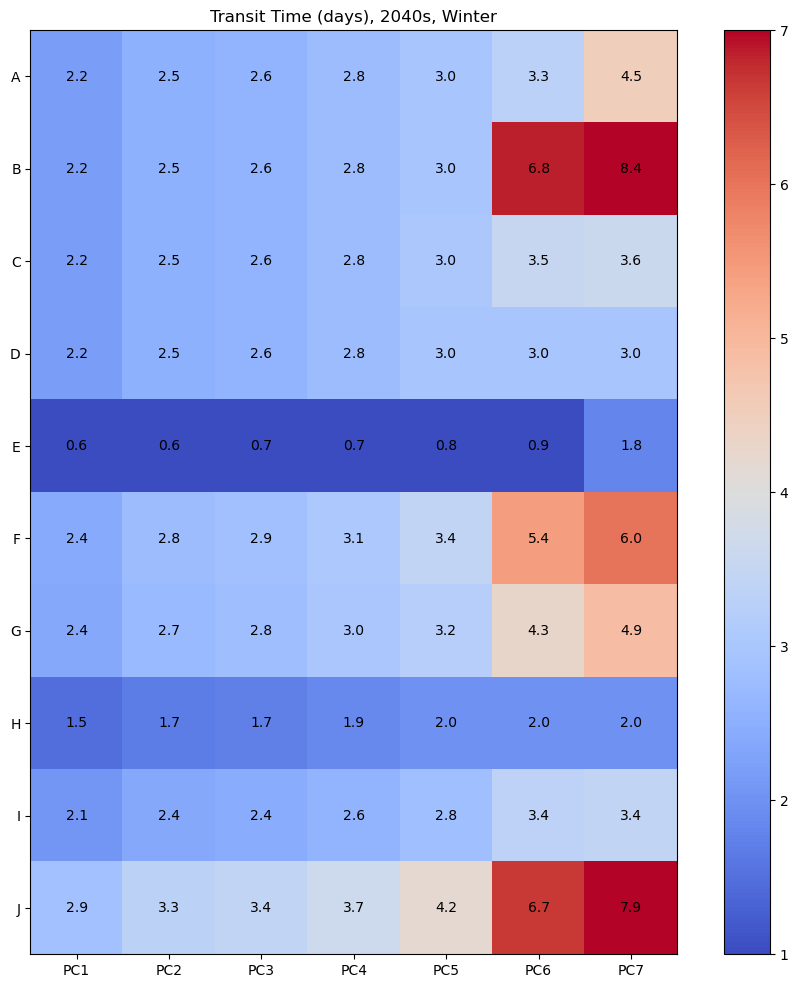

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(12, 12))
os.chdir('/users/lconlon/lookup3')
matrix=np.zeros((10,7))
decade=4 #0=2000 1=2010 2=2020 3=2030 4=2040
matrix[0,0:7]=mean_winterA[decade,:] 
matrix[1,0:7]=mean_winterB[decade,:]
matrix[2,0:7]=mean_winterC[decade,:]
matrix[3,0:7]=mean_winterD[decade,:]
matrix[4,0:7]=mean_winterE[decade,:]
matrix[5,0:7]=mean_winterF[decade,:]
matrix[6,0:7]=mean_winterG[decade,:]
matrix[7,0:7]=mean_winterH[decade,:]
matrix[8,0:7]=mean_winterI[decade,:]
matrix[9,0:7]=mean_winterJ[decade,:]

plt.imshow(matrix,cmap='coolwarm',vmin=1,vmax=7)
#axs.set_yticks()
axs.set_yticks([y  for y in range(10)],
                  labels=['A', 'B', 'C', 'D', 'E','F','G','H','I','J'])

axs.set_xticks([x  for x in range(7)],
                  labels=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7'])

plt.colorbar()
axs.set_title('Transit Time (days), 2040s, Winter')

for y in range(10):
    for x in range(7):
        if ~np.isnan(matrix[y, x]):
            plt.text(x , y , '%.1f' % matrix[y, x],
                 horizontalalignment='center',
                 verticalalignment='center'
                 )
#plt.show()

title='Lookup_2040s_winter.png'
fig.savefig(title)